refer `D03`,`D06`

In [1]:
import crypy as cp
import numpy as np
from matplotlib import pyplot as plt
from crypy_examples.atom_network import (
    draw_atom, 
    draw_bond,
    color_bond,
    color_Se,
    color_Ta,
    r_Se,
    r_Ta,
    r_bond,
    a1,a2,
    p1,p2,p3,p4        
)
from crypy_examples.chiral_interlock import lattice_points_in_hex
from matplotlib.colors import to_rgb

# region Fundamental Parameters
xylim = ((-10,10),(-10,10))

In [2]:
p1

array([0.66666667, 0.33333333])

In [3]:
color_Se_HA = [254,164,0]
color_Ta_HA = [0, 176, 240]
color_hollow = [255, 0, 150]
color_Se_vesta = [202,137,33]
color_Ta_vesta = [38,115,148]
hexer =  lambda rgb: '#{:02x}{:02x}{:02x}'.format(*rgb)

In [4]:
def draw(pos_CDW,clr_CDW=color_hollow):
    # region class setup for figure
    # region LEVEL 1: ATOMIC LATTICE
    pv = cp.PrimitiveVector2D(a1,a2)
    bss = cp.Basis2D(pv)
    # gen_atom_Ta = lambda x,y: draw_atom(x, y, radius=r_Ta, color_hex=color_Ta)
    gen_atom_Ta = lambda x,y: draw_atom(x, y, radius=r_Ta*.6*1.5, color_hex=hexer(color_Ta_HA))
    gen_atom_Se = lambda x,y: draw_atom(x, y, radius=r_Se*1.5, color_hex=hexer(color_Se_HA))
    # gen_bond = lambda x,y: draw_bond(x,y,r=r_bond*.6,facecolor=to_rgb(color_bond))
    gen_atom_Ta = lambda x,y: cp.Collection.Generator.gen_regular_polygon(
        3,x=x,y=y,r=.2,c=hexer(color_Ta_HA),phi=np.pi/2)
    gen_atom_Se = lambda x,y: cp.Collection.Generator.gen_regular_polygon(
        3,x=x,y=y,r=.2,c=hexer(color_Se_HA),phi=-np.pi/2)
    print("color_bond rgb:",to_rgb(color_bond))
    # bss.add_artist(gen_bond,(p1,p2),label = 'bond1')
    # bss.add_artist(gen_bond,(p1,p3),label = 'bond2')
    # bss.add_artist(gen_bond,(p2,p4),label = 'bond3')
    bss.add_artist(gen_atom_Ta,(p1),label='Ta')
    bss.add_artist(gen_atom_Se,(p2),label='Se')



    lp = cp.LatticePoints2D(pv) 
    lp.generate_points_by_xylim(*xylim)
    cry = cp.Crystal2D(bss,lp)
    # endregion

    # region LEVEL 2: CDW 
    pv_sup = pv.get_super_structure(3,3)
    bss_sup = cp.Basis2D(pv_sup)
    def gen_CDW(x,y):    
        ec = np.array(clr_CDW)/255
        ec = np.append(ec,0.6)
        cp.Collection.Generator.gen_regular_polygon(
        30,x=x,y=y,r=1,fc=(0,0,0,0),ec = ec)
        cp.Collection.Generator.gen_regular_polygon(
        30,x=x,y=y,r=.3,fc=(0,0,0,0),ec = ec)
    bss_sup.add_artist(gen_CDW,pos_CDW,label='CDW')
    lp_sup = cp.LatticePoints2D(pv_sup)   
    lp_sup.generate_points_by_xylim(*xylim)
    cry_sup = cp.Crystal2D(bss_sup,lp_sup)
    gen_domain = lambda x,y:cry_sup.plot_crystal(x,y)
    # endregion
    # endregion
    fig,ax  = cry.plot_crystal()
    cry_sup.plot_crystal()
    ax.set_xlim(-4,4)

    ax.set_ylim(-4,4)
    ax.set_xticks([])
    ax.set_yticks([])



color_bond rgb: (0.8784313725490196, 0.8784313725490196, 0.8784313725490196)
color_bond rgb: (0.8784313725490196, 0.8784313725490196, 0.8784313725490196)
color_bond rgb: (0.8784313725490196, 0.8784313725490196, 0.8784313725490196)


<Figure size 640x480 with 0 Axes>

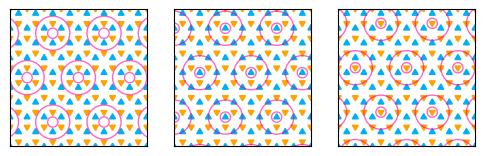

In [6]:
# region plot
plt.figure()
fig,axs = plt.subplots(1,3,figsize=(6,2))
plt.sca(axs[0])
draw(pos_CDW=[0,0],clr_CDW=color_hollow)
plt.sca(axs[1])
draw(pos_CDW=p1/3,clr_CDW=color_hollow)    
plt.sca(axs[2])
draw(pos_CDW=p2/3,clr_CDW=color_hollow)    
plt.savefig("D03_CDW_toon2.svg", bbox_inches='tight')

In [7]:
pv = cp.PrimitiveVector2D(a1,a2)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


def plot_plane_wave_lines(
    k,
    length=10,
    index_range=(-10, 10),
    origin=(0, 0),
    color='black',
    ax=None
):
    """
    Plot plane wave phase lines (k · r = c) for a 2D covector.

    Parameters
    ----------
    k : list, tuple, np.ndarray
        2D covector (kx, ky)
    length : float, optional
        Half-length of each line segment (default: 10)
    index_range : tuple(int, int), optional
        Range of phase indices (c values), inclusive (default: (-10, 10))
    origin : tuple(float, float), optional
        Shifted origin (default: (0, 0))
    color : str or list-like, optional
        Line color. Can be:
        - single color string (e.g., 'black', 'red')
        - list/array of colors for each line
    ax : matplotlib.axes.Axes, optional
        Existing axes to draw on

    Returns
    -------
    ax : matplotlib.axes.Axes
    lines : list of Line2D objects
    """

    # Convert input to numpy array
    k = np.asarray(k, dtype=float)
    if k.shape != (2,):
        raise ValueError("k must be a 2D vector with 2 components.")

    kx, ky = k
    x0, y0 = origin

    # Create axis if not provided
    if ax is None:
        fig, ax = plt.subplots()

    # Reject zero covector
    if np.linalg.norm(k) == 0:
        raise ValueError("Zero covector is not allowed.")

    # Direction vector of the line (perpendicular to k)
    direction = np.array([-ky, kx])
    direction = direction / np.linalg.norm(direction)

    i_min, i_max = index_range
    indices = list(range(i_min, i_max + 1))

    lines = []

    for idx, i in enumerate(indices):
        c = i

        # Shifted phase due to origin: k·(r - origin) = c
        c_shifted = c + kx * x0 + ky * y0

        # Find a base point on the line
        if abs(ky) > 1e-8:
            x_base = 0
            y_base = c_shifted / ky
        else:
            x_base = c_shifted / kx
            y_base = 0

        base_point = np.array([x_base, y_base])

        # Create two endpoints of the line segment
        p1 = base_point + length * direction
        p2 = base_point - length * direction

        # Handle color (single or per-line)
        if isinstance(color, (list, tuple, np.ndarray)):
            line_color = color[idx % len(color)]
        else:
            line_color = color

        line, = ax.plot(
            [p1[0], p2[0]],
            [p1[1], p2[1]],
            color=line_color
        )

        lines.append(line)

    ax.set_aspect('equal')


    return ax, lines




color_bond rgb: (0.8784313725490196, 0.8784313725490196, 0.8784313725490196)


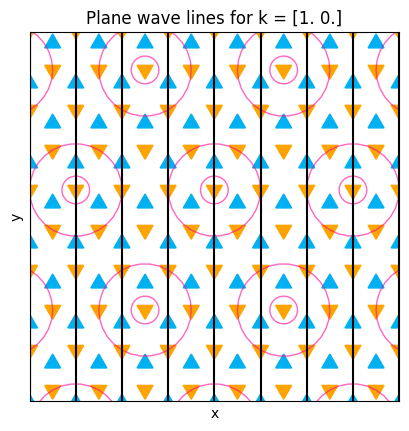

In [32]:
k = (1, 0)
# k = (-1/2, -np.sqrt(3)/2)
# k = (1/2, np.sqrt(3)/2)
ax, lines = plot_plane_wave_lines(k, color='black')
draw(pos_CDW=p2/3,clr_CDW=color_hollow)
plt.show()

In [30]:
class nullName:
    def add(a,b):
        return a+b

In [31]:
nullName.add(1,1)

2